In [1]:
# 调用包

# %%javascript 折叠命令
%matplotlib inline
# import find_motifs as fdm
from scipy import stats
import copy
import networkx as nx
from collections import Counter
from math import sqrt
from matplotlib.pyplot import MultipleLocator
from statistics import mean
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import time
import math
import json
import csv
import os
import shutil
import seaborn as sns
import numpy as np
import pandas as pd
import tempfile
# from pandas.io.json import json_normalize
from pandas.core.frame import DataFrame
import networkx as nx
from collections import deque
# 忽略警告
import warnings
warnings.filterwarnings('ignore')
from sklearn import metrics
from sklearn.model_selection import train_test_split
from xgboost import plot_importance
from sklearn import preprocessing
from sklearn.utils import shuffle
#from sklearn.metrics import plot_confusion_matrix
lbl = preprocessing.LabelEncoder()
import xgboost as xgb

In [2]:

# 计算函数

#计算网络最大深度
def get_max_depth(G):
    roots = (v for v, d in G.in_degree() if d == 0)
    leaves = (v for v, d in G.out_degree() if d == 0)
    all_paths = []
    for root in roots:
        for leaf in leaves:
            paths = nx.all_simple_paths(G, root, leaf)
            all_paths.extend(paths)
    return max(len(i) for i in all_paths) - 1 

# 计算网络结构异质性特征
def heterogeneity(G):
    nk = [G.degree[n] for n in G.nodes()]
    nkk = [G.degree[n] * G.degree[n] for n in G.nodes()]
    tmp_k = np.average(nk)
    tmp_kk = np.sqrt(np.average(nkk))
    h = round(tmp_kk / tmp_k, 3)
    return h

# 计算级联病毒性特征
def pure_cascade_virality(G):
    '''G is a directed graph(tree)'''
    if not nx.is_weakly_connected(G):
        # return None
        return
    nodes = [k for (k,v) in G.out_degree() if v>0]  # non-leaf nodes
    virality = 0
    for source in nodes:
        path_lens = nx.single_source_shortest_path_length(G, source)  # shortest path length
        path_lens = {k: v for k, v in path_lens.items() if v > 0}    # filter 0
        virality += np.array(list(path_lens.values())).mean()    # mean length from source to other nodes
    return virality

# 计算时效模体度
def timemotif(network,t):
    global G0
    M3 = []
    bm = []
    dm = []
    list_i = []
    list_j = []
    for i in network:
        if network.out_degree(i) > 0:
            for j in network.successors(i):
                a = network.nodes[j]['time'] - network.nodes[i]['time']
                if a < t:
                    list_i.append(i)
                    list_j.append(j)
                    c = {'a':list_i,'b':list_j}
                    df_c = DataFrame(c)
                    G0 = nx.from_pandas_edgelist(df_c, 'a', 'b' ,create_using=nx.DiGraph())
    for m in G0:
        if G0.out_degree(m) > 1:
            M3.append(G0.out_degree(m))
    for k in M3:
        bm.append(k*(k-1)/2)

    for p in G0:
        if G0.out_degree(p) > 0:
            for q in G0.successors(p):
                if G0.out_degree(q) > 0:
                    dm.append(G0.out_degree(q))
                        
    return int(sum(bm)),int(sum(dm)),int(G0.number_of_nodes())

def total_out_degree(digraph):
    """
    计算有向图的总出度数

    参数:
        digraph (networkx.DiGraph): 有向图

    返回:
        int: 总出度数
    """
    # 获取每个节点的出度
    out_degrees = dict(digraph.out_degree())

    # 计算总出度数
    total_out_degree = sum(out_degrees.values())

    return total_out_degree

In [1]:
import networkx as nx
import time
from collections import deque
import copy

def Feasibility(G,edge1,edge2):
    """
    :param G:
    :param edge1:
    :param edge2:
    :return:
    """
    result= False
    hasEdge = G.has_edge(edge1[0], edge1[1])
    hasEdge1 = G.has_edge(edge2[0], edge2[1])
    hasEdge2 = G.has_edge(edge1[1], edge1[0])
    hasEdge3 = G.has_edge(edge2[1], edge2[0])

    if(hasEdge == hasEdge1  and hasEdge2 == hasEdge3):
        result=True
    return result


def Feasibility_weighted(G,G_motif,n1,n2,N1,node,hasEdge):
    """
    在无向加权网络中
    根据同构条件判断是否是要寻找的模体
    :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
    :param G_motif: 模体图,可以有向或者无向但必须与图G一致
    :param n1: 模体网络G_motif中的节点
    :param n2: 模体网络G_motif中的节点
    :param N1: 目标网络G中的节点
    :param node: 目标网络G中的节点
    :param hasEdge: n1和n2之间是否有正向边
    :return True or False: 代表是否构成模体
    """
    if hasEdge:
        if(G_motif[n1][n2]['weight'])!= (G[N1][node]['weight']):
            return False

    return True

def Feasibility_weighted_directed(G,G_motif,n1,n2,N1,node,hasEdge,hasEdge1):
    """
    根据同构条件判断是否是要寻找的模体
    :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
    :param G_motif: 模体图,可以有向或者无向但必须与图G一致
    :param n1: 模体网络G_motif中的节点
    :param n2: 模体网络G_motif中的节点
    :param N1: 目标网络G中的节点
    :param node: 目标网络G中的节点
    :param hasEdge: n1和n2之间是否有正向边
    :param hasEdge1: n2和n1之间是否有反向边
    :return True or False: 代表是否构成模体
    """
    if hasEdge1:
        if (G_motif[n2][n1]['weight'])!= (G[node][N1]['weight']):
            return False

    if hasEdge:
        if (G_motif[n1][n2]['weight'])!= (G[N1][node]['weight']):
            return False

    return True

def preSort(G_motif,G2_node_list):
    """
    预处理：排序，调整搜索顺序，将度大的放前面，这样约束越多，剪枝越多，搜索越快。
    :param G_motif:
    :param G2_node_list:
    :param n_G2:
    """
    n_G2=len(G2_node_list)
    for i in range(1,n_G2):
        for j in range(0,n_G2-i):
            if G_motif.degree(G2_node_list[j+1])>G_motif.degree(G2_node_list[j]):
                t=G2_node_list[j]
                G2_node_list[j]=G2_node_list[j+1]
                G2_node_list[j+1]=t
    return G2_node_list

def DFS_nodes(M, m_nodes, rat, n, minQ, MS, deep, work, candi,result):

    if deep == len(m_nodes):
        if minQ >work:
            minQ=work
            for i in range(deep):
                result[i] = MS[i]
        # print(MS,minQ,work)
        return result,minQ
    work1=0
    candi1=0
    for node in m_nodes:
        if node in MS[:deep]:
            continue
        candi1 = candi
        for node1 in MS[:deep]:
            if M.has_edge(node,node1):
                candi1=rat*candi1
        candi1=candi1*n
        work1 = n * candi - candi1 + work
        MS[deep]=node
        result, minQ= DFS_nodes(M, m_nodes, rat, n, minQ, MS, deep + 1, work1, candi1, result)
    return result,minQ

def Motif_node_sort(M,m_nodes,deeps):
    """
    找到一种最快的搜索顺序
    :param M:
    :param m_nodes:
    :param deeps:
    :return:
    """
    rat=0.5
    n=10
    minQ=99999999999999
    MS=['*' for x in range(len(m_nodes))]
    work=0
    candi=1
    m_nodes1=['*' for x in range(len(m_nodes))]
    if deeps==1:
        MS[0]=m_nodes[0]
    if deeps == 2:
        MS[0]=m_nodes[0]
        MS[1]=m_nodes[1]
    m_nodes1,minQ=DFS_nodes(M, m_nodes, rat, n, minQ, MS, deeps, work, candi,m_nodes1)
    return m_nodes1


def find_motif(G,Motif,G_node_list,G2_node_list,n_G2,MS,deeps,derepeat,weighted=False):
    # start = time.time()
    number = 0  # 存储模体数量
    deep = deeps
    SL=[]
    for i in range(n_G2-deeps):
        SL.append([])
        for j in range(0,n_G2-deeps-i):
            SL[i].append([])

    searchset = set(G_node_list)
    searchset = searchset - set(MS[0:deeps])
    for j in range(deeps, n_G2):
        SL[0][j - deeps] = searchset
    for i in range(deeps):
        ss = []
        neighbor1 = searchset & set(G.neighbors(MS[i]))
        neighbor2 = searchset - set(G.neighbors(MS[i]))
        for j in range(deeps, n_G2):
            hasEdge = Motif.has_edge(G2_node_list[i], G2_node_list[j])
            if (hasEdge):
                searchset1 = neighbor1
            else:
                searchset1 = neighbor2

            if weighted:
                for k in searchset1:
                    if (not Feasibility_weighted(G, Motif, G2_node_list[i], G2_node_list[j], MS[i], k,hasEdge)):
                        ss.append(k)
            searchset1=searchset1-set(ss)
            if (not searchset1):
                return 0
            if i == 0:
                SL[0][j-deeps] =  searchset1
            else:
                SL[0][j - deeps] = set(SL[0][j - deeps]) & searchset1

    if n_G2 - deeps < 2:
        return len(SL[0][0])
    Quelist = []
    for i in range(n_G2 - deeps):
        Quelist.append(deque())

    Quelist[deep - deeps].extend(SL[deep - deeps][0])
    ddd = False
    while (1):
        if deep == n_G2 - 1:
            number +=len(SL[deep-deeps][0])
            # print(MS, SL[deep - deeps][0]);
            deep -= 1


        while (not Quelist[deep - deeps]):
            deep -= 1
            if deep < deeps:
                return number

        MS[deep] = Quelist[deep - deeps].pop()
        neighbor1 = set(G.neighbors(MS[deep]))
        for i in range(1,n_G2-deep):
            searchset = SL[deep-deeps][i]
            searchset = searchset - set(MS[0:deep+1])
            hasEdge= Motif.has_edge(G2_node_list[deep], G2_node_list[deep+i])
            if (hasEdge):
                searchset = searchset & neighbor1
            else:
                searchset = searchset - neighbor1

            if (not searchset):
                ddd = False
                break
            if derepeat[deep+i]!=-1 and derepeat[deep+i]<=deep:

                rrr=[]
                for k in list(searchset):
                    if int(k) <int(MS[derepeat[deep+i]]):
                        rrr.append(k)
                searchset= searchset - set(rrr)
            ss=[]
            if weighted:
                for k in searchset:
                    if (not Feasibility_weighted(G, Motif, G2_node_list[deep], G2_node_list[deep+i], MS[deep], k,hasEdge)):
                        ss.append(k)
            searchset = searchset-set(ss)
            if (not searchset):
                ddd = False
                break
            else:
                SL[deep - deeps+1][i-1] = searchset
                ddd = True
        if ddd:
            deep += 1
            if deep < n_G2-1:
                Quelist[deep - deeps].extend(SL[deep-deeps][0])

def find_motif_directed(G,Motif,G_node_list,G2_node_list,n_G2,MS,deeps,derepeat,weighted=False):
    # start = time.time()
    # print("@@@@@",G2_node_list)
    edgelist = list(nx.edges(G))
    edgelist1 = []
    for i in edgelist:
        edgelist1.append((i[1], i[0]))

    G2 = nx.DiGraph()
    G2.add_nodes_from(G_node_list)
    G2.add_edges_from(edgelist1)

    number = 0  # 存储模体数量
    deep = deeps
    SL=[]
    for i in range(n_G2-deeps):
        SL.append([])
        for j in range(0,n_G2-deeps-i):
            SL[i].append([])

    searchset = set(G_node_list) - set(MS[0:deeps])
    for j in range(deeps, n_G2):
        SL[0][j - deeps] = searchset

    for i in range(deeps):
        ss = []
        neighbor1 = searchset & set(G.neighbors(MS[i]))
        neighbor2 = searchset - set(G.neighbors(MS[i]))
        neighbor3 = searchset & set(G2.neighbors(MS[i]))
        neighbor4 = searchset - set(G2.neighbors(MS[i]))
        for j in range(deeps, n_G2):
            hasEdge = Motif.has_edge(G2_node_list[i], G2_node_list[j])
            hasEdge1 = Motif.has_edge(G2_node_list[j], G2_node_list[i])
            if (hasEdge):
                searchset1 = neighbor1
            else:
                searchset1 = neighbor2
            if (hasEdge1):
                searchset1 = searchset1 & neighbor3
            else:
                searchset1 = searchset1 & neighbor4
            if weighted:
                for k in searchset1:
                    if ( not Feasibility_weighted_directed(G, Motif, G2_node_list[i], G2_node_list[j], MS[i], k,hasEdge,hasEdge1)):
                        ss.append(k)
            searchset1=searchset1-set(ss)
            if (not searchset1):
                return 0

            if i == 0:
                SL[0][j - deeps] = searchset1
            else:
                SL[0][j - deeps] = set(SL[0][j - deeps]) & searchset1

    if n_G2 - deeps < 2:
        return len(SL[0][0])
    Quelist = []
    for i in range(n_G2 - deeps - 1):
        Quelist.append(deque())

    Quelist[deep - deeps].extend(SL[deep - deeps][0])
    ddd = False
    while (1):
        if  deep == n_G2 - 1:
            number += len(SL[deep-deeps][0])
            deep -= 1
        while (not Quelist[deep - deeps]):
            deep -= 1
            if deep < deeps:
                return number
        # if derepeat[deep] != -1:
        #     MS[deep] = Quelist[deep - deeps].pop()
        #
        #     while(int(MS[deep]) < int(MS[derepeat[deep]])):
        #         while (not Quelist[deep - deeps]):
        #             deep -= 1
        #             if deep < deeps:
        #                 return number
        #         MS[deep] = Quelist[deep - deeps].pop()
        #         if derepeat[deep] == -1:
        #             break
        # else:
        #     MS[deep] = Quelist[deep - deeps].pop()
        MS[deep] = Quelist[deep - deeps].pop()
        neighbor1 = set(G.neighbors(MS[deep]))
        neighbor2 = set(G2.neighbors(MS[deep]))
        for i in range(1,n_G2-deep):
            searchset = SL[deep-deeps][i]
            searchset = searchset - set(MS[0:deep+1])
            hasEdge= Motif.has_edge(G2_node_list[deep], G2_node_list[deep+i])
            hasEdge1 = Motif.has_edge(G2_node_list[deep+i], G2_node_list[deep])
            if (hasEdge):
                searchset = searchset & neighbor1
            else:
                searchset = searchset - neighbor1
            if (hasEdge1):
                searchset = searchset & neighbor2
            else:
                searchset = searchset - neighbor2

            if (not searchset):
                ddd = False
                break

            if derepeat[deep + i] != -1 and derepeat[deep + i] <= deep:
                rrr = []
                for k in list(searchset):
                    if int(k) < int(MS[derepeat[deep + i]]):
                        rrr.append(k)
                searchset = searchset - set(rrr)

            ss=[]
            if weighted:
                for k in searchset:
                    if ( not Feasibility_weighted_directed(G, Motif, G2_node_list[deep], G2_node_list[deep+i], MS[deep], k,hasEdge,hasEdge1)):
                        ss.append(k)
            searchset=searchset-set(ss)
            if (not searchset):
                ddd = False
                break
            else:
                SL[deep - deeps+1][i-1] = searchset
                ddd = True
        if ddd:
            deep += 1
            if deep < n_G2-1:
                Quelist[deep - deeps].extend(SL[deep-deeps][0])



def combine_motif_list(motif_list,MS):
    ll=copy.deepcopy(list(MS))
    motif_list.append(ll)
    # print(motif_list)

def filter_greater(node_list,num1):
    result=[]
    for i in node_list:
        if int(i) > num1:
            result.append(i)
    return result

def find_motif_list(G,Motif,G_node_list,G2_node_list,n_G2,MS,deeps,derepeat,weighted=False):
    # start = time.time()
    motif_list =[]
    number = 0  # 存储模体数量
    deep = deeps
    SL=[]
    for i in range(n_G2-deeps):
        SL.append([])
        for j in range(0,n_G2-deeps-i+1):
            SL[i].append([])

    searchset = set(G_node_list)
    searchset = searchset - set(MS[0:deeps])
    for j in range(deeps, n_G2):
        SL[0][j - deeps] = searchset

    for i in range(deeps):
        ss = []
        neighbor1 = searchset & set(G.neighbors(MS[i]))
        neighbor2 = searchset - set(G.neighbors(MS[i]))
        for j in range(deeps, n_G2):
            hasEdge=Motif.has_edge(G2_node_list[i], G2_node_list[j])
            if (hasEdge):
                searchset1 = neighbor1
            else:
                searchset1 = neighbor2

            if weighted:
                for k in searchset1:
                    if (not Feasibility_weighted(G, Motif, G2_node_list[i], G2_node_list[j], MS[i], k,hasEdge)):
                        ss.append(k)
                searchset1=searchset1-set(ss)
            if (not searchset1):
                return motif_list
            if i == 0:
                SL[0][j-deeps] =  searchset1
            else:
                SL[0][j - deeps] = set(SL[0][j - deeps]) & searchset1

    if n_G2 - deeps < 2:
        for i in SL[0][0]:
            MS[n_G2-1]=i
            combine_motif_list(motif_list, MS)
        return motif_list
    Quelist = []
    for i in range(n_G2 - deeps):
        Quelist.append(deque())

    Quelist[deep - deeps].extend(SL[deep - deeps][0])
    ddd = False

    while (1):
        # print("++++++",motif_list, MS)
        if deep > n_G2 - 1:
            deep -= 1
            # if derepeat[deep] !=-1:
            #     print("++++++++++++++",deep)
            #     SL[deep-deeps][0]=filter_greater(SL[deep-deeps][0],int(MS[derepeat[deep]]))
            number += len(SL[deep-deeps][0])
            combine_motif_list(motif_list,MS)

        while (not Quelist[deep - deeps]):
            deep -= 1
            if deep < deeps:
                return motif_list

        if derepeat[deep] != -1:
            MS[deep] = Quelist[deep - deeps].pop()
            while(int(MS[deep]) < int(MS[derepeat[deep]])):
                while (not Quelist[deep - deeps]):
                    deep -= 1
                    if deep < deeps:
                        return motif_list
                MS[deep] = Quelist[deep - deeps].pop()
                if derepeat[deep] == -1:
                    break
        else:
            MS[deep] = Quelist[deep - deeps].pop()
        neighbor1 = set(G.neighbors(MS[deep]))
        for i in range(1,n_G2-deep):
            searchset = set(SL[deep-deeps][i])
            searchset = searchset - set(MS[0:deep+1])
            hasEdge= Motif.has_edge(G2_node_list[deep], G2_node_list[deep+i])
            if (hasEdge):
                searchset = searchset & neighbor1
            else:
                searchset = searchset - neighbor1

            if (not searchset):
                ddd = False
                break
            ss=[]

            if weighted:
                for k in searchset:
                    if (not Feasibility_weighted(G, Motif, G2_node_list[deep], G2_node_list[deep+i], MS[deep], k,hasEdge)):
                        ss.append(k)
            searchset=searchset-set(ss)
            if (not searchset):
                ddd = False
                break
            else:
                SL[deep - deeps+1][i-1] = searchset
                ddd = True
        if ddd:
            deep += 1
            if deep < n_G2:
                Quelist[deep - deeps].extend(SL[deep-deeps][0])

def find_motif_directed_list(G,Motif,G_node_list,G2_node_list,n_G2,MS,deeps,derepeat,weighted=False):
    # start = time.time()
    # print("@@@@@",G2_node_list)
    motif_list = []
    edgelist = list(nx.edges(G))
    edgelist1 = []
    for i in edgelist:
        edgelist1.append((i[1], i[0]))
    G2 = nx.DiGraph()
    G2.add_nodes_from(G_node_list)
    G2.add_edges_from(edgelist1)

    number = 0  # 存储模体数量
    deep = deeps
    SL=[]
    for i in range(n_G2-deeps):
        SL.append([])
        for j in range(0,n_G2-deeps-i+1):
            SL[i].append([])
    searchset = set(G_node_list) - set(MS[0:deeps])
    for j in range(deeps, n_G2):
        SL[0][j - deeps] = searchset

    for i in range(deeps):

        ss = []
        neighbor1 = searchset & set(G.neighbors(MS[i]))
        neighbor2 = searchset - set(G.neighbors(MS[i]))
        neighbor3 = searchset & set(G2.neighbors(MS[i]))
        neighbor4 = searchset - set(G2.neighbors(MS[i]))
        for j in range(deeps, n_G2):
            hasEdge=Motif.has_edge(G2_node_list[i], G2_node_list[j])
            hasEdge1 = Motif.has_edge(G2_node_list[j], G2_node_list[i])
            if (hasEdge):
                searchset1 = neighbor1
            else:
                searchset1 = neighbor2
            if (hasEdge1):
                searchset1 = searchset1 & neighbor3
            else:
                searchset1 = searchset1 & neighbor4
            if weighted:
                for k in searchset1:
                    if ( not Feasibility_weighted_directed(G, Motif, G2_node_list[i], G2_node_list[j], MS[i], k,hasEdge,hasEdge1)):
                        ss.append(k)
            searchset1=searchset1-set(ss)
            if (not searchset1):
                return motif_list

            if i == 0:
                SL[0][j-deeps]=  searchset1
            else:
                SL[0][j - deeps] = set(SL[0][j - deeps]) & searchset1

    if n_G2 - deeps < 2:
        for i in SL[0][0]:
            MS[n_G2-1]=i
            combine_motif_list(motif_list, MS)

        return motif_list
        # return SL[0][0]
    Quelist = []
    for i in range(n_G2 - deeps):
        Quelist.append(deque())

    Quelist[deep - deeps].extend(SL[deep - deeps][0])
    ddd = False

    while (1):
        if  deep > n_G2 - 1:
            deep -= 1
            # if derepeat[deep] !=-1:
            #     print("++++++++++++++",deep)
            #     SL[deep-deeps][0]=filter_greater(SL[deep-deeps][0],int(MS[derepeat[deep]]))
            number += len(SL[deep-deeps][0])
            combine_motif_list(motif_list, MS)
        while (not Quelist[deep - deeps]):
            deep -= 1
            if deep < deeps:
                return motif_list

        if derepeat[deep] != -1:
            MS[deep] = Quelist[deep - deeps].pop()

            while(int(MS[deep]) < int(MS[derepeat[deep]])):
                while (not Quelist[deep - deeps]):
                    deep -= 1
                    if deep < deeps:
                        return motif_list
                MS[deep] = Quelist[deep - deeps].pop()
                if derepeat[deep] == -1:
                    break
        else:
            MS[deep] = Quelist[deep - deeps].pop()
        neighbor1 = set(G.neighbors(MS[deep]))
        neighbor2 = set(G2.neighbors(MS[deep]))
        for i in range(1,n_G2-deep):
            searchset = SL[deep-deeps][i]
            searchset = searchset - set(MS[0:deep+1])
            hasEdge= Motif.has_edge(G2_node_list[deep], G2_node_list[deep+i])
            hasEdge1 = Motif.has_edge(G2_node_list[deep+i], G2_node_list[deep])
            if (hasEdge):
                searchset = searchset & neighbor1
            else:
                searchset = searchset - neighbor1
            if (hasEdge1):
                searchset = searchset & neighbor2
            else:
                searchset = searchset - neighbor2

            if (not searchset):
                ddd = False
                break
            ss=[]
            if weighted:
                for k in searchset:
                    if ( not Feasibility_weighted_directed(G, Motif, G2_node_list[deep], G2_node_list[deep+i], MS[deep], k,hasEdge,hasEdge1)):
                        ss.append(k)
            searchset=searchset-set(ss)
            if (not searchset):
                ddd = False
                break
            else:
                SL[deep - deeps+1][i-1] = searchset
                ddd = True
        if ddd:
            deep += 1
            if deep < n_G2:
                Quelist[deep - deeps].extend(SL[deep-deeps][0])


def get_node_group(G2_node_list,n_G2,repetitions):

    nodes_group={}
    for i in G2_node_list:
        nodes_group[i]={}
        for j in G2_node_list:
            nodes_group[i][j]=-1
    for i in range(n_G2):
        for j in range(len(repetitions)):
            for k in range(len(repetitions)):
                nodes_group[repetitions[j][i]][repetitions[k][i]] = 1
                nodes_group[repetitions[k][i]][repetitions[j][i]] = 1
    return nodes_group

def Build_Motif_Tree(motif, nodelist):
    motif_tree={}
    mark={}
    # nodelist=list(nx.nodes(motif))
    for i in nodelist:
        mark[i]=0
        motif_tree[i]=[]
    mark[nodelist[0]]=1
    build_tree(motif,mark,nodelist[0],motif_tree)
    return motif_tree

def build_tree(motif,mark,node,motif_tree):
    a=list(motif.nodes())
    b=[]
    for i in a:
        if mark[i] ==0 and (motif.has_edge(i,node) or motif.has_edge(node,i)):
            b.append(i)
            mark[i]=1
    # if b==[]:
    #     return
    motif_tree[node]=b
    for i in motif_tree[node]:
        build_tree(motif,mark,i,motif_tree)

#
# def get_prevent_repetition_list(motif,G2_node_list,len1,MS,deep, weighted,derepet):
#     repetitions= find_motif_list(motif,motif, G2_node_list, G2_node_list, len1, MS, deep,derepet, weighted)
#     if len(repetitions)==1:
#         return derepet
#     nodes_group = get_node_group(G2_node_list,len1,repetitions)
#     for i in range(len1):
#         k=-1
#         s=0
#         for j in range(len1):
#             if(nodes_group[G2_node_list[i]][G2_node_list[j]]==1 and derepet[j]==-1):
#                 derepet[j]=k
#                 k=j
#                 s+=1
#         if(s>1):
#             break
#     # print(derepet)
#     return get_prevent_repetition_list(motif, G2_node_list, len1, MS, deep, weighted,derepet)


def get_prevent_repetition_list(motif,G2_node_list,len1,repetitions):
    isconnect=True
    direc=nx.is_directed(motif)
    if not direc:
        isconnect = nx.is_connected(motif)
    if( (not isconnect) and (not direc)):
        moti = nx.Graph()
        # edge_ss=[]
        moti.add_nodes_from(G2_node_list)
        for i in G2_node_list:
            for j in G2_node_list:
                if(i!=j):
                    if( not motif.has_edge(i,j)):
                        moti.add_edge(i,j)
                        # edge_ss.append((i,j))
                    if( not motif.has_edge(j,i)):
                        moti.add_edge(j, i)
                        # edge_ss.append((j, i))
        # moti.add_edges_from(edge_ss)
        motif = moti


    nodes_group = get_node_group(G2_node_list,len1,repetitions)


    motif_tree = Build_Motif_Tree(motif,G2_node_list)
    # print(motif_tree)
    mapnodelist={}
    for i in range(len(G2_node_list)):
        mapnodelist[G2_node_list[i]]=i

    derepet = [-1 for i in range(len1)]

    for i in G2_node_list[1:]:
        if nodes_group[G2_node_list[0]][i]==1:
            derepet[mapnodelist[i]]=0

    mark = {}
    for i in G2_node_list:
        mark[i]=0
    for node in G2_node_list:
        for i in range(len(motif_tree[node])):
            if mark[motif_tree[node][i]]== 0:
                aaa=[]
                aaa.append(motif_tree[node][i])
                mark[motif_tree[node][i]] = 1
                for j in range(len(motif_tree[node])):
                    if i < j:
                        if nodes_group[motif_tree[node][i]][motif_tree[node][j]] == 1:
                            if Feasibility(motif,(node,motif_tree[node][i]),(node,motif_tree[node][j])):
                                aaa.append(motif_tree[node][j])
                                mark[motif_tree[node][j]]=1
                            # aaa.append(motif_tree[node][j])
                            # mark[motif_tree[node][j]]=1
                bbb=[]
                for k in G2_node_list:
                    if k in aaa:
                        bbb.append(k)
                for k in range(len(bbb)):
                    if k==0:
                        continue
                    derepet[mapnodelist[bbb[k]]]=mapnodelist[bbb[k-1]]


    return derepet

##############################################################################


def node_orbit_motif_degree(G,G_motif,node,orbit_node,directed=False,weighted=False):
    """
        计算node节点在模体的某个轨道中所参与的模体数量
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但必须与图G一致
        :param node: 图G中的一个节点
        :param orbit_node: motif中的一个节点代表模体的一个轨道
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :点模体数
    """

    # start = time.time()
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    len1 = len(G2_node_list)
    # 根据轨道调整节点顺序
    for nod in range(len1):
        if G2_node_list[nod] == orbit_node:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[0]
    G2_node_list[0] = orbit_node


    # G2_node_list[1:len1]=preSort(G_motif, G2_node_list[1:len1])  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list, 1)



    MS = ['*' for x in range(len1)]
    node_motif_number = 0
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        # print(repetitions)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # print(derepeat)
        # 下面查找node节点的模体数
        MS[0] = node
        node_motif_number = find_motif_directed(G, G_motif, G_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        MS[0] = G2_node_list[0]
        # a = find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # 下面查找node节点的模体数
        MS[0] = node
        node_motif_number = find_motif(G, G_motif, G_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        MS[0] = G2_node_list[0]
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
    # end = time.time()
    # print("node_motif_num总共用时{}秒".format((end - start)))
    #结果是需要除以重复的数
    return node_motif_number

def edge_orbit_motif_degree(G,G_motif,edge,orbit_edge,directed=False,weighted=False):
    """
        计算edge作为模体的orbit所参与的模体数量
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但必须与图G一致
        :param edge: 图G中的一条边
        :param orbit_edge: motif中的一个边代表模体的一个边轨道
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :返回值是边模体数
    """
    # if directed:
    #     twoWay = False
    #     if not G.has_edge(edge[0], edge[1]):
    #         print("There is no such edge in the network.",edge)
    #         return 0
    #     if G.has_edge(edge[1], edge[0]):
    #         twoWay = True
    # else :
    #     twoWay =True

    twoWay = False
    if (not G.has_edge(edge[0], edge[1])) and (not G.has_edge(edge[1], edge[0])):
        print("There is no such edge in the network.")
        twoWay = True
    if G.has_edge(edge[1], edge[0]) and G.has_edge(edge[0], edge[1]):
        twoWay = True

    # start = time.time()
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    len1 = len(G2_node_list)
    # 根据轨道调整节点顺序
    for nod in range(len1):
        if G2_node_list[nod] == orbit_edge[0]:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[0]
    G2_node_list[0] = orbit_edge[0]
    for nod in range(len1):
        if G2_node_list[nod] == orbit_edge[1]:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[1]
    G2_node_list[1] = orbit_edge[1]


    # G2_node_list[2:len1]=preSort(G_motif, G2_node_list[2:len1])  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list, 2)
    MS = ['*' for x in range(len1)]
    edge_motif_number=0

    if directed:

        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list,len1, repetitions)
        if (derepeat[1] != -1):
            twoWay = False
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat,weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # 计算边模体数量01的顺序不同
        MS[0] = edge[0]
        MS[1] = edge[1]
        edge_motif_number = find_motif_directed(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        # a = find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        if twoWay:  # 如果是双向边还需要查找反方向的模体数
            MS[0] = edge[1]
            MS[1] = edge[0]
            edge_motif_number += find_motif_directed(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
            MS[0] = G2_node_list[1]
            MS[1] = G2_node_list[0]
            # a += find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)

    else:

        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        if (derepeat[1] != -1):
            twoWay = False

        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        #------------------------------#
        MS[0] = edge[0]
        MS[1] = edge[1]
        edge_motif_number= find_motif(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        if twoWay:  # 如果是双向边还需要查找反方向的模体数
            MS[0] = edge[1]
            MS[1] = edge[0]
            edge_motif_number += find_motif(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat,weighted)
            MS[0] = G2_node_list[1]
            MS[1] = G2_node_list[0]
            # a += find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
    # end = time.time()
    # print("edge_motif_num总共用时{}秒".format((end - start)))
    # 结果是需要除以重复的数
    return edge_motif_number


def motif_num(G,G_motif,directed=True,weighted=False):
    """
        计算某种模体在网络中的数量
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但类型必须与图G一致
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :返回值是某种模体总数
    """
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    n_G2 = len(G2_node_list)
    # start = time.time()

    # G2_node_list=preSort(G_motif, G2_node_list)  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list,0)

    MS = ['*' for x in range(n_G2)]
    total_motif_number = 0
    # repetitions = 0
    # 计算模体总数量
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        derepeat = [-1 for i in range(n_G2)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, n_G2, repetitions)
#         print(derepeat)
        total_motif_number = find_motif_directed(G, G_motif, G_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        # a=find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)

    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        derepeat = [-1 for i in range(n_G2)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0,derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, n_G2, repetitions)
        # print(derepeat)
        total_motif_number = find_motif(G, G_motif, G_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        # print(a)
        # print(total_motif_number)
    # end = time.time()
    # print("total_motif_num总共用时{}秒".format((end - start)))
    # 结果是需要除以重复的数
    return total_motif_number



def motif_total_list(G,G_motif,directed=True,weighted=False):
    """
        找到网络中的所有模体，并以节点和 边的列表输出
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但类型必须与图G一致
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :返回值是构成模体的节点集合列表和边集合列表
    """
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    n_G2 = len(G2_node_list)
    G2_node_list = Motif_node_sort(G_motif, G2_node_list,0)

    MS = ['*' for x in range(n_G2)]


    # 计算模体总数量
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        derepeat = [-1 for i in range(n_G2)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, n_G2, repetitions)
        total_motif = find_motif_directed_list(G, G_motif, G_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)


    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        derepeat = [-1 for i in range(n_G2)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, n_G2, MS, 0,derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, n_G2, repetitions)
        # print(derepeat)
        total_motif = find_motif_list(G, G_motif, G_node_list, G2_node_list, n_G2, MS, 0, derepeat, weighted)

    motifss = total_motif

    # print("motif num :",len(motifss))
    motif_edge=[]
    for i in range(len(motifss)):
        motif_edge.append([])
    if directed:
        for i in range(len(G2_node_list)):
            for j in  range(len(G2_node_list)):
                if(i!=j):
                    if(G_motif.has_edge(G2_node_list[i],G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i],motifss[k][j]))
    else:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (j>i):
                    if(G_motif.has_edge(G2_node_list[i],G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i],motifss[k][j]))
    # print(motif_edge)
    return motifss




def node_orbit(G,directed=False,weighted=False):
    """
    计算节点轨道
    :param G:
    :param directed:
    :param weighted:
    :return: 节点轨道
    """
    node_list1 = list(G.nodes)
    node_num = len(node_list1)
    # start = time.time()
    MS = ['*' for x in range(node_num)]
    derepeat = [-1 for i in range(node_num)]
    if directed:
        repetitions = find_motif_directed_list(G, G, node_list1, node_list1, node_num, MS, 0, derepeat,weighted)
    else:
        repetitions = find_motif_list(G, G, node_list1, node_list1, node_num, MS, 0, derepeat, weighted)


    repelen=len(repetitions)
    orbit_list=[]

    sum=0
    nodesss=[]
    for i in range(node_num):
        orbit = set()
        if (repetitions[0][i] in nodesss):
            continue
        for j in range(repelen):
            orbit.add(repetitions[j][i])
            nodesss.append(repetitions[j][i])
        sum=sum+len(orbit)
        orbit_list.append(list(orbit))
        if(sum >= node_num):
            break
    # print(orbit_list)
    return orbit_list


def Isomorphism_Self_search(G,directed=False,weighted=False):
    """
    自同构搜索，用来找到模体的轨道
    :param G:
    :param directed:
    :param weighted:
    :return:
    """
    G_node_list = list(nx.nodes(G))
    n_G2 = len(G_node_list)
    G2_node_list=G_node_list
    MS = ['*' for x in range(n_G2)]
    derepeat = [-1 for i in range(n_G2)]
    # 计算模体总数量
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        total_motif = find_motif_directed_list(G, G, G_node_list, G_node_list, n_G2, MS, 0, derepeat, weighted)
    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        total_motif = find_motif_list(G, G, G_node_list, G_node_list, n_G2, MS, 0, derepeat, weighted)
    motifss = total_motif

    # print("motif num :",len(motifss))
    motif_edge = []
    for i in range(len(motifss)):
        motif_edge.append([])
    if directed:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (i != j):
                    if (G.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    else:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (j > i):
                    if (G.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    # print(motif_edge)
    return motifss, motif_edge

def edge_orbit(G,directed=False,weighted=False):
    """
    模体的边轨道
    :param G:
    :param directed:
    :param weighted:
    :return:
    """
    edgelist=list(G.edges())
    nodes,edges=Isomorphism_Self_search(G,directed,weighted)
    m=len(edges)
    n=0
    if(m>0):
        n=len(edges[0])
    edge_orbits=[]
    edge_set=set()
    for i in range(n):
        edge_set=set()
        for j in range(m):
            if edges[j][i] in edgelist:
                edge_set.add(edges[j][i])
                edgelist.remove(edges[j][i])
        if(len(list(edge_set))>0):
            edge_orbits.append(list(edge_set))

    # print(edge_orbits)
    return edge_orbits





def node_motif_degree(G,G_motif,node,directed=False,weighted=False):
    """
           计算node节点参与的模体数量
           :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
           :param G_motif: 模体图,可以有向或者无向但必须与图G一致
           :param node: 图G中的一个节点
           :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
           :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
           :return :点模体数
    """
    result=0
    orbit_list=node_orbit(G_motif)
    for i in range(len(orbit_list)):
        # start = time.time()
        result += node_orbit_motif_degree(G, G_motif, node,orbit_list[i][0], directed, weighted)  # 点模体
    return result

def edge_motif_degree(G,G_motif,edge,directed=False,weighted=False):
    """
           计算边edge参与构成模体的数量
           :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
           :param G_motif: 模体图,可以有向或者无向但必须与图G一致
           :param edge: 图G中的一条边
           :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
           :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
           :return :边模体数
    """
    result=0
    orbit_list=edge_orbit(G_motif, directed, weighted)
    for i in range(len(orbit_list)):
        # start = time.time()
        result += edge_orbit_motif_degree(G, G_motif, edge,orbit_list[i][0], directed, weighted)  # 点模体
    return result


def node_coverage_rate_of_motif(G,G_motif,directed=False, weighted=False):
    """
    模体的节点覆盖率
    :param G:
    :param G_motif:
    :param directed:
    :param weighted:
    :return:
    """
    G_node_list = list(nx.nodes(G))
    node_num=len(G_node_list)
    in_motif=0
    for node in G_node_list:
        a = node_motif_degree(G, G_motif, node, directed, weighted)
        if a>0:
            in_motif+=1
    return in_motif/node_num

def edge_coverage_rate_of_motif(G,G_motif,directed=False, weighted=False):
    """
    模体的边覆盖率
    :param G:
    :param G_motif:
    :param directed:
    :param weighted:
    :return:
    """
    G_edge_list = list(nx.edges(G))
    edge_num = len(G_edge_list)
    in_motif = 0
    for edge in G_edge_list:
        a = edge_motif_degree(G, G_motif, edge, directed, weighted)
        if a > 0:
            in_motif += 1
    return in_motif / edge_num


def node_orbit_motif_list(G,G_motif,node,orbit_node,directed=False,weighted=False):
    """
        找到网络中节点node参与在某轨道的所有模体，并以节点和 边的列表输出
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但必须与图G一致
        :param node: 图G中的一个节点
        :param orbit_node: motif中的一个节点代表模体的一个轨道
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :模体的节点和边的列表
    """

    # start = time.time()
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    len1 = len(G2_node_list)
    # 根据轨道调整节点顺序
    for nod in range(len1):
        if G2_node_list[nod] == orbit_node:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[0]
    G2_node_list[0] = orbit_node


    # G2_node_list[1:len1]=preSort(G_motif, G2_node_list[1:len1])  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list, 1)
    MS = ['*' for x in range(len1)]
    node_motif_number = 0
    if directed:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        # print(repetitions)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # 下面查找node节点的模体数
        MS[0] = node
        node_motif = find_motif_directed_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        MS[0] = G2_node_list[0]
        # a = find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
    else:
        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        # print(repetitions)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # print(derepeat)
        # 下面查找node节点的模体数
        MS[0] = node
        node_motif = find_motif_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
        MS[0] = G2_node_list[0]
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 1, derepeat, weighted)
    # end = time.time()
    # print("node_motif_num总共用时{}秒".format((end - start)))
    #结果是需要除以重复的数

    motifss = node_motif

    # print("motif num :", len(motifss))
    motif_edge = []
    for i in range(len(motifss)):
        motif_edge.append([])
    if directed:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (i != j):
                    if (G_motif.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    else:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (j > i):
                    if (G_motif.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    # print(motif_edge)
    return motifss, motif_edge

def edge_orbit_motif_list(G,G_motif,edge,orbit_edge,directed=False,weighted=False):
    """
        找到网络中边edge参与在某轨道的所有模体，并以节点和 边的列表输出
        :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
        :param G_motif: 模体图,可以有向或者无向但必须与图G一致
        :param edge: 图G中的一条边
        :param orbit_edge: motif中的一个边代表模体的一个边轨道
        :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
        :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
        :return :返回值是边模体集合
    """
    # if directed:
    #     twoWay = False
    #     if not G.has_edge(edge[0], edge[1]):
    #         print("There is no such edge in the network.",edge)
    #         return 0
    #     if G.has_edge(edge[1], edge[0]):
    #         twoWay = True
    # else :
    #     twoWay =True

    twoWay = False
    if (not G.has_edge(edge[0], edge[1])) and (not G.has_edge(edge[1], edge[0])):
        print("There is no such edge in the network.")
        twoWay = True
    if G.has_edge(edge[1], edge[0]) and G.has_edge(edge[0], edge[1]):
        twoWay = True


    # start = time.time()
    G_node_list = list(nx.nodes(G))
    G2_node_list = list(nx.nodes(G_motif))
    len1 = len(G2_node_list)
    # 根据轨道调整节点顺序
    for nod in range(len1):
        if G2_node_list[nod] == orbit_edge[0]:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[0]
    G2_node_list[0] = orbit_edge[0]
    for nod in range(len1):
        if G2_node_list[nod] == orbit_edge[1]:
            ab = nod
            break
    G2_node_list[ab] = G2_node_list[1]
    G2_node_list[1] = orbit_edge[1]


    # G2_node_list[2:len1]=preSort(G_motif, G2_node_list[2:len1])  # 调整搜索顺序
    G2_node_list = Motif_node_sort(G_motif, G2_node_list, 2)
    MS = ['*' for x in range(len1)]
    edge_motif_number=0


    if directed:

        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list,len1, repetitions)
        if (derepeat[1] != -1):
            twoWay = False

        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_directed_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat,weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        # 计算边模体数量01的顺序不同
        MS[0] = edge[0]
        MS[1] = edge[1]
        edge_motif = find_motif_directed_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        # a = find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        if twoWay:  # 如果是双向边还需要查找反方向的模体数
            MS[0] = edge[1]
            MS[1] = edge[0]
            edge_motif.extend( find_motif_directed_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted))
            MS[0] = G2_node_list[1]
            MS[1] = G2_node_list[0]
            # a += find_motif_directed(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)

    else:

        # 搜索模体图中的模体数，如果大于1，说明有对称结构导致重复计算。
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 0, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)

        if (derepeat[1] != -1):
            twoWay = False
        derepeat = [-1 for i in range(len1)]
        repetitions = find_motif_list(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        derepeat = get_prevent_repetition_list(G_motif, G2_node_list, len1, repetitions)
        #------------------------------#
        MS[0] = edge[0]
        MS[1] = edge[1]
        edge_motif= find_motif_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        MS[0] = G2_node_list[0]
        MS[1] = G2_node_list[1]
        # a = find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
        if twoWay:  # 如果是双向边还需要查找反方向的模体数
            MS[0] = edge[1]
            MS[1] = edge[0]
            edge_motif.extend(  find_motif_list(G, G_motif, G_node_list, G2_node_list, len1, MS, 2, derepeat,weighted))
            MS[0] = G2_node_list[1]
            MS[1] = G2_node_list[0]
            # a += find_motif(G_motif, G_motif, G2_node_list, G2_node_list, len1, MS, 2, derepeat, weighted)
    # end = time.time()
    # print("edge_motif_num总共用时{}秒".format((end - start)))
    # 结果是需要除以重复的数

    motifss = edge_motif

    # print("motif num :", len(motifss))
    motif_edge = []
    for i in range(len(motifss)):
        motif_edge.append([])
    if directed:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (i != j):
                    if (G_motif.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    else:
        for i in range(len(G2_node_list)):
            for j in range(len(G2_node_list)):
                if (j > i):
                    if (G_motif.has_edge(G2_node_list[i], G2_node_list[j])):
                        for k in range(len(motifss)):
                            motif_edge[k].append((motifss[k][i], motifss[k][j]))
    # print(motif_edge)
    return motifss, motif_edge


def node_motif_list(G,G_motif,node,directed=False,weighted=False):
    """
           找到网络中节点node参与的所有模体，并以节点和 边的列表输出
           :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
           :param G_motif: 模体图,可以有向或者无向但必须与图G一致
           :param node: 图G中的一个节点
           :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
           :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
           :return :点模体集合
    """
    result_node = []
    result_edge = []
    orbit_list=node_orbit(G_motif)
    for i in range(len(orbit_list)):
        # start = time.time()
        nodes, edges =node_orbit_motif_list(G, G_motif, node,orbit_list[i][0], directed, weighted)
        result_node.extend(nodes)  # 点模体
        result_edge.extend(edges)
    return result_node,result_edge

def edge_motif_list(G,G_motif,edge,directed=False,weighted=False):
    """
           找到网络中边edge参与的所有模体，并以节点和 边的列表输出
           :param G: 图或（网络），可以是有向或无向图，是networkx.Graph() 或 networkx.DiGraph()
           :param G_motif: 模体图,可以有向或者无向但必须与图G一致
           :param edge: 图G中的一条边
           :param directed: 是否是有向图，是有向图值为True，否则为False，默认为无向图False
           :param weighted: 是否具有权重，是否是加权网络，若是值为True，若否值为False，默认为False,符号网络视为加权网络。
           :return :边模体集合
    """
    result_node=[]
    result_edge=[]
    orbit_list=edge_orbit(G_motif, directed, weighted)
    for i in range(len(orbit_list)):
        # start = time.time()
        nodes,edges=edge_orbit_motif_list(G, G_motif, edge, orbit_list[i][0], directed, weighted)
        result_node.extend(nodes)  # 点模体
        result_edge.extend(edges)
    return result_node,result_edge


# def FMCA(G, motif,directed=False,weight=False):
#     n = len(motif)
#     result = []
#     for i in range(n):
#         res = motif_num(G, motif[i],directed=directed,weighted=weight)
#         result.append(res)
#     return result

def FMCA(G, motif,directed=False,weight=False):
    n = len(motif)
    result = []
    for i in range(n):
        res = motif_total_list(G, motif[i],directed=directed,weighted=weight)
        result.append(res)
    return result



if __name__ == "__main__":
    pass

In [3]:
import pandas as pd
# Create a directed graph
# tree = nx.DiGraph()
# tree.add_edges_from(edges)

g3_1 = nx.DiGraph()
g3_1.add_nodes_from([1, 2, 3])
g3_1.add_edges_from([(1, 2), (1, 3)])
g3_2 = nx.DiGraph()
g3_2.add_nodes_from([1, 2, 3])
g3_2.add_edges_from([(1, 2), (2, 3)])

g4_1 = nx.DiGraph()
g4_1.add_nodes_from([1, 2, 3, 4])
g4_1.add_edges_from([(1, 2), (1, 3), (1, 4)])
g4_2 = nx.DiGraph()
g4_2.add_nodes_from([1, 2, 3, 4])
g4_2.add_edges_from([(1, 2), (2, 3), (2, 4)])
g4_3 = nx.DiGraph()
g4_3.add_nodes_from([1, 2, 3, 4])
g4_3.add_edges_from([(1, 2), (1, 3), (3, 4)])
g4_4 = nx.DiGraph()
g4_4.add_nodes_from([1, 2, 3, 4])
g4_4.add_edges_from([(1, 2), (2, 3), (3, 4)])


g5_1 = nx.DiGraph()
g5_1.add_nodes_from([1, 2, 3, 4, 5])
g5_1.add_edges_from([(1, 2), (1, 3), (1, 4), (1, 5)])
g5_2 = nx.DiGraph()
g5_2.add_nodes_from([1, 2, 3, 4, 5])
g5_2.add_edges_from([(1, 2), (2, 3), (1, 4), (1, 5)])
g5_3 = nx.DiGraph()
g5_3.add_nodes_from([1, 2, 3, 4, 5])
g5_3.add_edges_from([(1, 2), (2, 3), (1, 4), (4, 5)])
g5_4 = nx.DiGraph()
g5_4.add_nodes_from([1, 2, 3, 4, 5])
g5_4.add_edges_from([(1, 2), (2, 3), (2, 4), (1, 5)])
g5_5 = nx.DiGraph()
g5_5.add_nodes_from([1, 2, 3, 4, 5])
g5_5.add_edges_from([(1, 2), (2, 3), (3, 4), (1, 5)])
g5_6 = nx.DiGraph()
g5_6.add_nodes_from([1, 2, 3, 4, 5])
g5_6.add_edges_from([(1, 2), (2, 3), (2, 4), (2, 5)])
g5_7 = nx.DiGraph()
g5_7.add_nodes_from([1, 2, 3, 4, 5])
g5_7.add_edges_from([(1, 2), (2, 3), (3, 4), (2, 5)])
g5_8 = nx.DiGraph()
g5_8.add_nodes_from([1, 2, 3, 4, 5])
g5_8.add_edges_from([(1, 2), (2, 3), (3, 4), (3, 5)])
g5_9 = nx.DiGraph()
g5_9.add_nodes_from([1, 2, 3, 4, 5])
g5_9.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5)])



In [9]:
import os
import pandas as pd
import networkx as nx

a = 3600
list2 = [30, 60, 180, 600, 1800, 3600]

for b in list2:

    # 原始数据路径
    path6 = r'F:\weibo\from_to_t_time_时刻\rumor'
    path7 = r'F:\weibo\from_to_t_time_时刻\ture'
    
    path_list6 = os.listdir(path6)
    path_list7 = os.listdir(path7)
    
    # --- 处理 'rumor' (fake) 路径下的数据 ---
    list1 = []
    for filename in path_list6:
        path_csv6 = os.path.join(path6, filename)
        df = pd.read_csv(path_csv6)
        
        # 严格保留原始双重过滤逻辑
        df = df[df['时刻'] <= a]
        df = df[df['time'] <= b]
        
        G = nx.from_pandas_edgelist(df, 'parent', 'mid', create_using=nx.DiGraph())
        
        # 使用显式调用的 motif_num 风格
        list1.append([
            filename[:-4], G.number_of_nodes(), 
            motif_num(G, g3_1), motif_num(G, g3_2), 
            motif_num(G, g4_1), motif_num(G, g4_2), motif_num(G, g4_3), motif_num(G, g4_4),
            motif_num(G, g5_1), motif_num(G, g5_2), motif_num(G, g5_3), motif_num(G, g5_4), 
            motif_num(G, g5_5), motif_num(G, g5_6), motif_num(G, g5_7), motif_num(G, g5_8), motif_num(G, g5_9)
        ])
        
        name = ['id', 'scale', 'm3_1', 'm3_2', 'm4_1', 'm4_2', 'm4_3', 'm4_4',
                'm5_1', 'm5_2', 'm5_3', 'm5_4', 'm5_5', 'm5_6', 'm5_7', 'm5_8', 'm5_9']
        
        # 逻辑保持不变：在文件循环内保存
        test1 = pd.DataFrame(columns=name, data=list1)
        save_path_fake = f'早期识别/{a}/fake/{b}.csv'
        os.makedirs(os.path.dirname(save_path_fake), exist_ok=True)
        test1.to_csv(save_path_fake, encoding='utf-8', index=False)
    
    # --- 处理 'ture' (real) 路径下的数据 ---
    list1 = [] # 清空用于 real 数据
    for filename in path_list7:
        path_csv7 = os.path.join(path7, filename)
        df = pd.read_csv(path_csv7)
        
        # 严格保留原始双重过滤逻辑
        df = df[df['时刻'] <= a]
        df = df[df['time'] <= b]
        
        G = nx.from_pandas_edgelist(df, 'parent', 'mid', create_using=nx.DiGraph())
        
        # 使用显式调用的 motif_num 风格
        list1.append([
            filename[:-4], G.number_of_nodes(), 
            motif_num(G, g3_1), motif_num(G, g3_2), 
            motif_num(G, g4_1), motif_num(G, g4_2), motif_num(G, g4_3), motif_num(G, g4_4),
            motif_num(G, g5_1), motif_num(G, g5_2), motif_num(G, g5_3), motif_num(G, g5_4), 
            motif_num(G, g5_5), motif_num(G, g5_6), motif_num(G, g5_7), motif_num(G, g5_8), motif_num(G, g5_9)
        ])
        
        # 逻辑保持不变：在文件循环内保存
        test1 = pd.DataFrame(columns=name, data=list1)
        save_path_real = f'早期识别/{a}/real/{b}.csv'
        os.makedirs(os.path.dirname(save_path_real), exist_ok=True)
        test1.to_csv(save_path_real, encoding='utf-8', index=False)

print("✅ Early Recognition Analysis Completed.")

✅ Early Recognition Analysis Completed.


In [41]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# 路径设置
output_fake_path = r'早期识别/600/拼接后的假新闻数据.csv'
output_real_path = r'早期识别/600/拼接后的真实新闻数据.csv'

# 初始化 LabelEncoder
lbl = LabelEncoder()

# 读取拼接后的假新闻和真实新闻数据
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

# 添加标签列
fake_data['label'] = 1  # 假新闻
real_data['label'] = 0  # 真实新闻

# 随机抽样，确保样本平衡
real_data = real_data.sample(len(fake_data), replace=True)  # 确保样本平衡

# 合并假新闻和真实新闻数据
df = pd.concat([fake_data, real_data], ignore_index=True)

# 标签编码
df['label'] = lbl.fit_transform(df['label'].astype(str))

# 归一化特征列（假设特征从第二列到倒数第二列）
df1 = df.iloc[:, :-1].apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))

# 存储每次训练的评估结果
list_all_results = []

# 循环进行多次训练和评估
for i in range(100):
    print(f'---------- Iteration {i+1} ----------')

    # 切分数据，每次迭代时不设置random_state，这样可以确保数据每次都打乱
    label = df['label']
    train_x, test_x, train_y, test_y = train_test_split(df1, label, test_size=0.2)  # 不指定 random_state

    # 转换为XGBoost格式
    dtrain = xgb.DMatrix(train_x, label=train_y)
    dtest = xgb.DMatrix(test_x)

    # 设置XGBoost模型参数
    params = {'booster': 'gbtree', 'objective': 'binary:logistic', 'eval_metric': 'rmse',
              'max_depth': 2, 'lambda': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
              'min_child_weight': 2, 'eta': 0.25, 'seed': 0, 'nthread': 8, 'silent': 0}
    watchlist = [(dtrain, 'train')]

    # 训练模型
    model = xgb.train(params, dtrain, num_boost_round=500)

    # 预测
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5) * 1  # 预测结果转换为0或1

    # 计算各类评估指标
    ACC = float('%.3f' % metrics.accuracy_score(test_y, y_pred))
    Recall = float('%.3f' % metrics.recall_score(test_y, y_pred))
    F1 = float('%.3f' % metrics.f1_score(test_y, y_pred))
    Precesion = float('%.3f' % metrics.precision_score(test_y, y_pred))

    # 保存每次评估结果
    list_all_results.append({
        'Iteration': i + 1,
        'Accuracy': ACC,
        'Recall': Recall,
        'F1 Score': F1,
        'Precision': Precesion
    })

# 将所有结果保存为CSV文件
results_df = pd.DataFrame(list_all_results)
results_df.to_csv(r'早期识别/1识别结果识别结果_all_iterations.csv', index=False)

print("All classification results saved to 360时刻识别结果_all_iterations.csv")


---------- Iteration 1 ----------
---------- Iteration 2 ----------
---------- Iteration 3 ----------
---------- Iteration 4 ----------
---------- Iteration 5 ----------
---------- Iteration 6 ----------
---------- Iteration 7 ----------
---------- Iteration 8 ----------
---------- Iteration 9 ----------
---------- Iteration 10 ----------
---------- Iteration 11 ----------
---------- Iteration 12 ----------
---------- Iteration 13 ----------
---------- Iteration 14 ----------
---------- Iteration 15 ----------
---------- Iteration 16 ----------
---------- Iteration 17 ----------
---------- Iteration 18 ----------
---------- Iteration 19 ----------
---------- Iteration 20 ----------
---------- Iteration 21 ----------
---------- Iteration 22 ----------
---------- Iteration 23 ----------
---------- Iteration 24 ----------
---------- Iteration 25 ----------
---------- Iteration 26 ----------
---------- Iteration 27 ----------
---------- Iteration 28 ----------
---------- Iteration 29 -----

In [43]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# 路径设置
output_fake_path = r'早期识别/1200/拼接后的假新闻数据.csv'
output_real_path = r'早期识别/1200/拼接后的真实新闻数据.csv'

# 初始化 LabelEncoder
lbl = LabelEncoder()

# 读取拼接后的假新闻和真实新闻数据
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

# 添加标签列
fake_data['label'] = 1  # 假新闻
real_data['label'] = 0  # 真实新闻

# 随机抽样，确保样本平衡
real_data = real_data.sample(len(fake_data), replace=True)  # 确保样本平衡

# 合并假新闻和真实新闻数据
df = pd.concat([fake_data, real_data], ignore_index=True)

# 标签编码
df['label'] = lbl.fit_transform(df['label'].astype(str))

# 归一化特征列（假设特征从第二列到倒数第二列）
df1 = df.iloc[:, :-1].apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))

# 存储每次训练的评估结果
list_all_results = []

# 循环进行多次训练和评估
for i in range(100):
    print(f'---------- Iteration {i+1} ----------')

    # 切分数据，每次迭代时不设置random_state，这样可以确保数据每次都打乱
    label = df['label']
    train_x, test_x, train_y, test_y = train_test_split(df1, label, test_size=0.2)  # 不指定 random_state

    # 转换为XGBoost格式
    dtrain = xgb.DMatrix(train_x, label=train_y)
    dtest = xgb.DMatrix(test_x)

    # 设置XGBoost模型参数
    params = {'booster': 'gbtree', 'objective': 'binary:logistic', 'eval_metric': 'rmse',
              'max_depth': 2, 'lambda': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
              'min_child_weight': 2, 'eta': 0.25, 'seed': 0, 'nthread': 8, 'silent': 0}
    watchlist = [(dtrain, 'train')]

    # 训练模型
    model = xgb.train(params, dtrain, num_boost_round=500)

    # 预测
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5) * 1  # 预测结果转换为0或1

    # 计算各类评估指标
    ACC = float('%.3f' % metrics.accuracy_score(test_y, y_pred))
    Recall = float('%.3f' % metrics.recall_score(test_y, y_pred))
    F1 = float('%.3f' % metrics.f1_score(test_y, y_pred))
    Precesion = float('%.3f' % metrics.precision_score(test_y, y_pred))

    # 保存每次评估结果
    list_all_results.append({
        'Iteration': i + 1,
        'Accuracy': ACC,
        'Recall': Recall,
        'F1 Score': F1,
        'Precision': Precesion
    })

# 将所有结果保存为CSV文件
results_df = pd.DataFrame(list_all_results)
results_df.to_csv(r'早期识别/1200/1识别结果识别结果_all_iterations.csv', index=False)

print("All classification results saved to 360时刻识别结果_all_iterations.csv")


---------- Iteration 1 ----------
---------- Iteration 2 ----------
---------- Iteration 3 ----------
---------- Iteration 4 ----------
---------- Iteration 5 ----------
---------- Iteration 6 ----------
---------- Iteration 7 ----------
---------- Iteration 8 ----------
---------- Iteration 9 ----------
---------- Iteration 10 ----------
---------- Iteration 11 ----------
---------- Iteration 12 ----------
---------- Iteration 13 ----------
---------- Iteration 14 ----------
---------- Iteration 15 ----------
---------- Iteration 16 ----------
---------- Iteration 17 ----------
---------- Iteration 18 ----------
---------- Iteration 19 ----------
---------- Iteration 20 ----------
---------- Iteration 21 ----------
---------- Iteration 22 ----------
---------- Iteration 23 ----------
---------- Iteration 24 ----------
---------- Iteration 25 ----------
---------- Iteration 26 ----------
---------- Iteration 27 ----------
---------- Iteration 28 ----------
---------- Iteration 29 -----

In [45]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# 路径设置
output_fake_path = r'早期识别/1800/拼接后的假新闻数据.csv'
output_real_path = r'早期识别/1800/拼接后的真实新闻数据.csv'

# 初始化 LabelEncoder
lbl = LabelEncoder()

# 读取拼接后的假新闻和真实新闻数据
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

# 添加标签列
fake_data['label'] = 1  # 假新闻
real_data['label'] = 0  # 真实新闻

# 随机抽样，确保样本平衡
real_data = real_data.sample(len(fake_data), replace=True)  # 确保样本平衡

# 合并假新闻和真实新闻数据
df = pd.concat([fake_data, real_data], ignore_index=True)

# 标签编码
df['label'] = lbl.fit_transform(df['label'].astype(str))

# 归一化特征列（假设特征从第二列到倒数第二列）
df1 = df.iloc[:, :-1].apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))

# 存储每次训练的评估结果
list_all_results = []

# 循环进行多次训练和评估
for i in range(100):
    print(f'---------- Iteration {i+1} ----------')

    # 切分数据，每次迭代时不设置random_state，这样可以确保数据每次都打乱
    label = df['label']
    train_x, test_x, train_y, test_y = train_test_split(df1, label, test_size=0.2)  # 不指定 random_state

    # 转换为XGBoost格式
    dtrain = xgb.DMatrix(train_x, label=train_y)
    dtest = xgb.DMatrix(test_x)

    # 设置XGBoost模型参数
    params = {'booster': 'gbtree', 'objective': 'binary:logistic', 'eval_metric': 'rmse',
              'max_depth': 2, 'lambda': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
              'min_child_weight': 2, 'eta': 0.25, 'seed': 0, 'nthread': 8, 'silent': 0}
    watchlist = [(dtrain, 'train')]

    # 训练模型
    model = xgb.train(params, dtrain, num_boost_round=500)

    # 预测
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5) * 1  # 预测结果转换为0或1

    # 计算各类评估指标
    ACC = float('%.3f' % metrics.accuracy_score(test_y, y_pred))
    Recall = float('%.3f' % metrics.recall_score(test_y, y_pred))
    F1 = float('%.3f' % metrics.f1_score(test_y, y_pred))
    Precesion = float('%.3f' % metrics.precision_score(test_y, y_pred))

    # 保存每次评估结果
    list_all_results.append({
        'Iteration': i + 1,
        'Accuracy': ACC,
        'Recall': Recall,
        'F1 Score': F1,
        'Precision': Precesion
    })

# 将所有结果保存为CSV文件
results_df = pd.DataFrame(list_all_results)
results_df.to_csv(r'早期识别/1800/1识别结果识别结果_all_iterations.csv', index=False)

print("All classification results saved to 360时刻识别结果_all_iterations.csv")


---------- Iteration 1 ----------
---------- Iteration 2 ----------
---------- Iteration 3 ----------
---------- Iteration 4 ----------
---------- Iteration 5 ----------
---------- Iteration 6 ----------
---------- Iteration 7 ----------
---------- Iteration 8 ----------
---------- Iteration 9 ----------
---------- Iteration 10 ----------
---------- Iteration 11 ----------
---------- Iteration 12 ----------
---------- Iteration 13 ----------
---------- Iteration 14 ----------
---------- Iteration 15 ----------
---------- Iteration 16 ----------
---------- Iteration 17 ----------
---------- Iteration 18 ----------
---------- Iteration 19 ----------
---------- Iteration 20 ----------
---------- Iteration 21 ----------
---------- Iteration 22 ----------
---------- Iteration 23 ----------
---------- Iteration 24 ----------
---------- Iteration 25 ----------
---------- Iteration 26 ----------
---------- Iteration 27 ----------
---------- Iteration 28 ----------
---------- Iteration 29 -----

In [47]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# 路径设置
output_fake_path = r'早期识别/2400/拼接后的假新闻数据.csv'
output_real_path = r'早期识别/2400/拼接后的真实新闻数据.csv'

# 初始化 LabelEncoder
lbl = LabelEncoder()

# 读取拼接后的假新闻和真实新闻数据
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

# 添加标签列
fake_data['label'] = 1  # 假新闻
real_data['label'] = 0  # 真实新闻

# 随机抽样，确保样本平衡
real_data = real_data.sample(len(fake_data), replace=True)  # 确保样本平衡

# 合并假新闻和真实新闻数据
df = pd.concat([fake_data, real_data], ignore_index=True)

# 标签编码
df['label'] = lbl.fit_transform(df['label'].astype(str))

# 归一化特征列（假设特征从第二列到倒数第二列）
df1 = df.iloc[:, :-1].apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))

# 存储每次训练的评估结果
list_all_results = []

# 循环进行多次训练和评估
for i in range(100):
    print(f'---------- Iteration {i+1} ----------')

    # 切分数据，每次迭代时不设置random_state，这样可以确保数据每次都打乱
    label = df['label']
    train_x, test_x, train_y, test_y = train_test_split(df1, label, test_size=0.2)  # 不指定 random_state

    # 转换为XGBoost格式
    dtrain = xgb.DMatrix(train_x, label=train_y)
    dtest = xgb.DMatrix(test_x)

    # 设置XGBoost模型参数
    params = {'booster': 'gbtree', 'objective': 'binary:logistic', 'eval_metric': 'rmse',
              'max_depth': 2, 'lambda': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
              'min_child_weight': 2, 'eta': 0.25, 'seed': 0, 'nthread': 8, 'silent': 0}
    watchlist = [(dtrain, 'train')]

    # 训练模型
    model = xgb.train(params, dtrain, num_boost_round=500)

    # 预测
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5) * 1  # 预测结果转换为0或1

    # 计算各类评估指标
    ACC = float('%.3f' % metrics.accuracy_score(test_y, y_pred))
    Recall = float('%.3f' % metrics.recall_score(test_y, y_pred))
    F1 = float('%.3f' % metrics.f1_score(test_y, y_pred))
    Precesion = float('%.3f' % metrics.precision_score(test_y, y_pred))

    # 保存每次评估结果
    list_all_results.append({
        'Iteration': i + 1,
        'Accuracy': ACC,
        'Recall': Recall,
        'F1 Score': F1,
        'Precision': Precesion
    })

# 将所有结果保存为CSV文件
results_df = pd.DataFrame(list_all_results)
results_df.to_csv(r'早期识别/2400/1识别结果识别结果_all_iterations.csv', index=False)

print("All classification results saved to 360时刻识别结果_all_iterations.csv")


---------- Iteration 1 ----------
---------- Iteration 2 ----------
---------- Iteration 3 ----------
---------- Iteration 4 ----------
---------- Iteration 5 ----------
---------- Iteration 6 ----------
---------- Iteration 7 ----------
---------- Iteration 8 ----------
---------- Iteration 9 ----------
---------- Iteration 10 ----------
---------- Iteration 11 ----------
---------- Iteration 12 ----------
---------- Iteration 13 ----------
---------- Iteration 14 ----------
---------- Iteration 15 ----------
---------- Iteration 16 ----------
---------- Iteration 17 ----------
---------- Iteration 18 ----------
---------- Iteration 19 ----------
---------- Iteration 20 ----------
---------- Iteration 21 ----------
---------- Iteration 22 ----------
---------- Iteration 23 ----------
---------- Iteration 24 ----------
---------- Iteration 25 ----------
---------- Iteration 26 ----------
---------- Iteration 27 ----------
---------- Iteration 28 ----------
---------- Iteration 29 -----

In [49]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# 路径设置
output_fake_path = r'早期识别/3000/拼接后的假新闻数据.csv'
output_real_path = r'早期识别/3000/拼接后的真实新闻数据.csv'

# 初始化 LabelEncoder
lbl = LabelEncoder()

# 读取拼接后的假新闻和真实新闻数据
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

# 添加标签列
fake_data['label'] = 1  # 假新闻
real_data['label'] = 0  # 真实新闻

# 随机抽样，确保样本平衡
real_data = real_data.sample(len(fake_data), replace=True)  # 确保样本平衡

# 合并假新闻和真实新闻数据
df = pd.concat([fake_data, real_data], ignore_index=True)

# 标签编码
df['label'] = lbl.fit_transform(df['label'].astype(str))

# 归一化特征列（假设特征从第二列到倒数第二列）
df1 = df.iloc[:, :-1].apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))

# 存储每次训练的评估结果
list_all_results = []

# 循环进行多次训练和评估
for i in range(100):
    print(f'---------- Iteration {i+1} ----------')

    # 切分数据，每次迭代时不设置random_state，这样可以确保数据每次都打乱
    label = df['label']
    train_x, test_x, train_y, test_y = train_test_split(df1, label, test_size=0.2)  # 不指定 random_state

    # 转换为XGBoost格式
    dtrain = xgb.DMatrix(train_x, label=train_y)
    dtest = xgb.DMatrix(test_x)

    # 设置XGBoost模型参数
    params = {'booster': 'gbtree', 'objective': 'binary:logistic', 'eval_metric': 'rmse',
              'max_depth': 2, 'lambda': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
              'min_child_weight': 2, 'eta': 0.25, 'seed': 0, 'nthread': 8, 'silent': 0}
    watchlist = [(dtrain, 'train')]

    # 训练模型
    model = xgb.train(params, dtrain, num_boost_round=500)

    # 预测
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5) * 1  # 预测结果转换为0或1

    # 计算各类评估指标
    ACC = float('%.3f' % metrics.accuracy_score(test_y, y_pred))
    Recall = float('%.3f' % metrics.recall_score(test_y, y_pred))
    F1 = float('%.3f' % metrics.f1_score(test_y, y_pred))
    Precesion = float('%.3f' % metrics.precision_score(test_y, y_pred))

    # 保存每次评估结果
    list_all_results.append({
        'Iteration': i + 1,
        'Accuracy': ACC,
        'Recall': Recall,
        'F1 Score': F1,
        'Precision': Precesion
    })

# 将所有结果保存为CSV文件
results_df = pd.DataFrame(list_all_results)
results_df.to_csv(r'早期识别/3000/1识别结果识别结果_all_iterations.csv', index=False)

print("All classification results saved to 360时刻识别结果_all_iterations.csv")


---------- Iteration 1 ----------
---------- Iteration 2 ----------
---------- Iteration 3 ----------
---------- Iteration 4 ----------
---------- Iteration 5 ----------
---------- Iteration 6 ----------
---------- Iteration 7 ----------
---------- Iteration 8 ----------
---------- Iteration 9 ----------
---------- Iteration 10 ----------
---------- Iteration 11 ----------
---------- Iteration 12 ----------
---------- Iteration 13 ----------
---------- Iteration 14 ----------
---------- Iteration 15 ----------
---------- Iteration 16 ----------
---------- Iteration 17 ----------
---------- Iteration 18 ----------
---------- Iteration 19 ----------
---------- Iteration 20 ----------
---------- Iteration 21 ----------
---------- Iteration 22 ----------
---------- Iteration 23 ----------
---------- Iteration 24 ----------
---------- Iteration 25 ----------
---------- Iteration 26 ----------
---------- Iteration 27 ----------
---------- Iteration 28 ----------
---------- Iteration 29 -----

In [51]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder

# 路径设置
output_fake_path = r'早期识别/3600/拼接后的假新闻数据.csv'
output_real_path = r'早期识别/3600/拼接后的真实新闻数据.csv'

# 初始化 LabelEncoder
lbl = LabelEncoder()

# 读取拼接后的假新闻和真实新闻数据
fake_data = pd.read_csv(output_fake_path)
real_data = pd.read_csv(output_real_path)

# 添加标签列
fake_data['label'] = 1  # 假新闻
real_data['label'] = 0  # 真实新闻

# 随机抽样，确保样本平衡
real_data = real_data.sample(len(fake_data), replace=True)  # 确保样本平衡

# 合并假新闻和真实新闻数据
df = pd.concat([fake_data, real_data], ignore_index=True)

# 标签编码
df['label'] = lbl.fit_transform(df['label'].astype(str))

# 归一化特征列（假设特征从第二列到倒数第二列）
df1 = df.iloc[:, :-1].apply(lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)))

# 存储每次训练的评估结果
list_all_results = []

# 循环进行多次训练和评估
for i in range(100):
    print(f'---------- Iteration {i+1} ----------')

    # 切分数据，每次迭代时不设置random_state，这样可以确保数据每次都打乱
    label = df['label']
    train_x, test_x, train_y, test_y = train_test_split(df1, label, test_size=0.2)  # 不指定 random_state

    # 转换为XGBoost格式
    dtrain = xgb.DMatrix(train_x, label=train_y)
    dtest = xgb.DMatrix(test_x)

    # 设置XGBoost模型参数
    params = {'booster': 'gbtree', 'objective': 'binary:logistic', 'eval_metric': 'rmse',
              'max_depth': 2, 'lambda': 20, 'subsample': 0.8, 'colsample_bytree': 0.8,
              'min_child_weight': 2, 'eta': 0.25, 'seed': 0, 'nthread': 8, 'silent': 0}
    watchlist = [(dtrain, 'train')]

    # 训练模型
    model = xgb.train(params, dtrain, num_boost_round=500)

    # 预测
    ypred = model.predict(dtest)
    y_pred = (ypred >= 0.5) * 1  # 预测结果转换为0或1

    # 计算各类评估指标
    ACC = float('%.3f' % metrics.accuracy_score(test_y, y_pred))
    Recall = float('%.3f' % metrics.recall_score(test_y, y_pred))
    F1 = float('%.3f' % metrics.f1_score(test_y, y_pred))
    Precesion = float('%.3f' % metrics.precision_score(test_y, y_pred))

    # 保存每次评估结果
    list_all_results.append({
        'Iteration': i + 1,
        'Accuracy': ACC,
        'Recall': Recall,
        'F1 Score': F1,
        'Precision': Precesion
    })

# 将所有结果保存为CSV文件
results_df = pd.DataFrame(list_all_results)
results_df.to_csv(r'早期识别/3600/1识别结果识别结果_all_iterations.csv', index=False)

print("All classification results saved to 360时刻识别结果_all_iterations.csv")


---------- Iteration 1 ----------
---------- Iteration 2 ----------
---------- Iteration 3 ----------
---------- Iteration 4 ----------
---------- Iteration 5 ----------
---------- Iteration 6 ----------
---------- Iteration 7 ----------
---------- Iteration 8 ----------
---------- Iteration 9 ----------
---------- Iteration 10 ----------
---------- Iteration 11 ----------
---------- Iteration 12 ----------
---------- Iteration 13 ----------
---------- Iteration 14 ----------
---------- Iteration 15 ----------
---------- Iteration 16 ----------
---------- Iteration 17 ----------
---------- Iteration 18 ----------
---------- Iteration 19 ----------
---------- Iteration 20 ----------
---------- Iteration 21 ----------
---------- Iteration 22 ----------
---------- Iteration 23 ----------
---------- Iteration 24 ----------
---------- Iteration 25 ----------
---------- Iteration 26 ----------
---------- Iteration 27 ----------
---------- Iteration 28 ----------
---------- Iteration 29 -----

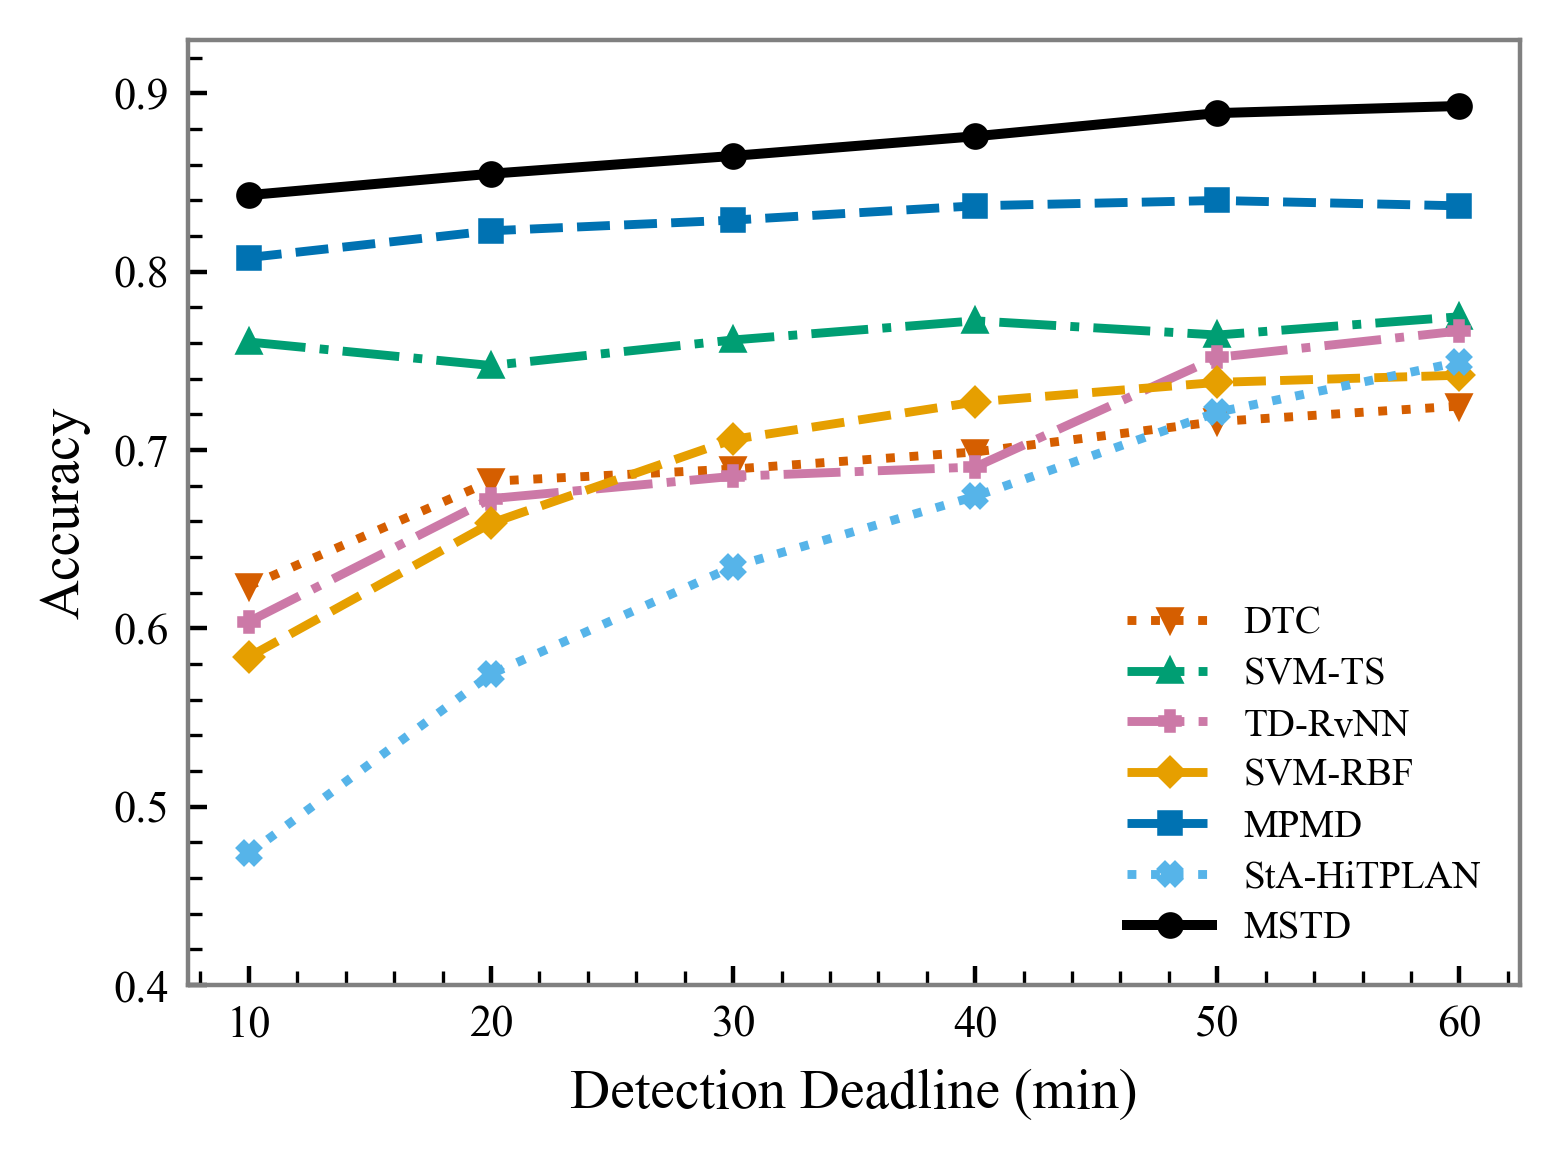

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

# ===== Global style =====
rcParams.update({
    "figure.dpi": 400,
    "savefig.dpi": 600,
    "font.family": "Times New Roman",
    "axes.unicode_minus": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "grid.color": "#E6E6E6",
    "grid.linestyle": "-",
    "grid.linewidth": 0.6,
})

# ===== Load data =====
file_path = r'前2h的微博数据检测准确率 - 副本.csv'
df = pd.read_csv(file_path)

x = df.iloc[:, 0]      # detection cut-off (hours)
Y = df.iloc[:, 1:]     # methods

# Map method names to column indices in Y (0-based)
series_map = {
    "DTC":          0,
    "SVM-TS":       1,
    "TD-RvNN":      2,
    "SVM-RBF":      3,
    "MPMD":         4,
    "StA-HiTPLAN":  5,
    "MSTD":         7,   # your main method
}

# Okabe–Ito colorblind-friendly palette
oi = {
    "black":      "#000000",
    "orange":     "#E69F00",
    "skyblue":    "#56B4E9",
    "green":      "#009E73",
    "yellow":     "#F0E442",
    "blue":       "#0072B2",
    "vermillion": "#D55E00",
    "purple":     "#CC79A7",
}

styles = {
    "MSTD":         dict(color=oi["black"],      lw=1.8, ls="-",  marker="o", ms=3.8, zorder=4),
    "MPMD":         dict(color=oi["blue"],       lw=1.6, ls="--", marker="s", ms=3.6, zorder=3),
    "SVM-TS":       dict(color=oi["green"],      lw=1.6, ls="-.", marker="^", ms=3.6, zorder=3),
    "DTC":          dict(color=oi["vermillion"], lw=1.6, ls=":",  marker="v", ms=3.6, zorder=3),
    "SVM-RBF":      dict(color=oi["orange"],     lw=1.6, ls="--", marker="D", ms=3.4, zorder=3),
    "TD-RvNN":      dict(color=oi["purple"],     lw=1.6, ls="-.", marker="P", ms=3.4, zorder=3),
    "StA-HiTPLAN":  dict(color=oi["skyblue"],    lw=1.6, ls=":",  marker="X", ms=3.6, zorder=3),
}

# ===== Plot =====
fig, ax = plt.subplots(figsize=(4, 3))

# Plot baselines first, then MSTD on top
for name in ["DTC", "SVM-TS", "TD-RvNN", "SVM-RBF", "MPMD", "StA-HiTPLAN"]:
    ax.plot(x, Y.iloc[:, series_map[name]], label=name, **styles[name])

ax.plot(x, Y.iloc[:, series_map["MSTD"]], label="MSTD", **styles["MSTD"])

# Axis labels in English
ax.set_xlabel("Detection Deadline (min)")
ax.set_ylabel("Accuracy")

# Limits, ticks, grid
ax.set_ylim(0.40, 0.93)
ax.set_xticks(x)
ax.minorticks_on()
ax.tick_params(axis="both", which="major", length=3.5, width=0.8, direction="in")
ax.tick_params(axis="both", which="minor", length=2.5, width=0.6, direction="in")
ax.grid(axis="y")

# Spine aesthetics
for spine in ax.spines.values():
    spine.set_color("#808080")
    spine.set_linewidth(0.8)

# Legend INSIDE the axes (top-left), semi-transparent white background
# 图例放在右下角，去边框、紧凑排列
leg = ax.legend(
    loc="lower right",          # 改为右下角
    frameon=False,              # 去掉边框
    handlelength=2.2,           # 线条长度
    borderaxespad=0.6,          # 边距
    fontsize=7,
    ncol=1,                     # 单列排列；若想更紧凑可设为2列
    columnspacing=0.8,
    labelspacing=0.4,
)

# 移除背景网格，让图表更简洁
ax.grid(False)

plt.tight_layout()
plt.savefig(r'early_detection.pdf', bbox_inches='tight')
plt.show()
